# 06 — Model Comparison

## TsHARP vs Random Forest vs XGBoost

This notebook compares three LST downscaling approaches implemented for the Lucknow study area:

1. TsHARP — traditional statistical/thermal sharpening approach
2. Random Forest — machine-learning regression approach
3. XGBoost — gradient-boosted tree regression approach

The purpose of this notebook is to evaluate the models under the established experimental framework and identify differences in predictive performance and spatial behaviour.

No new model is trained in this notebook. Results generated in the previous modelling notebooks are loaded or reproduced from their saved outputs for comparison.

### Comparison dimensions

The models will be compared using:

- MAE
- RMSE
- R²
- Bias / mean error
- Residual behaviour
- Performance across the observed LST range
- 30 m → 90 m consistency
- Spatial characteristics of the generated 30 m LST products

The final model selection will be based on the combined evidence rather than a single evaluation metric.

In [115]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

PROJECT_DIR = Path(
    r"D:\Projects\GeoAI-LST-Downscaling"
)

print("Project directory:", PROJECT_DIR)

Project directory: D:\Projects\GeoAI-LST-Downscaling


In [116]:
COARSE_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "lucknow"
    / "coarse"
)

DOWNSCALED_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "lucknow"
    / "downscaled"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "figures"
    / "lucknow"
)

lst_90m_path = (
    COARSE_DIR
    / "lst_90m_lucknow.tif"
)

print("Coarse LST:", lst_90m_path)
print("Downscaled directory:", DOWNSCALED_DIR)
print("Figures directory:", FIGURES_DIR)

Coarse LST: D:\Projects\GeoAI-LST-Downscaling\data\processed\lucknow\coarse\lst_90m_lucknow.tif
Downscaled directory: D:\Projects\GeoAI-LST-Downscaling\data\processed\lucknow\downscaled
Figures directory: D:\Projects\GeoAI-LST-Downscaling\figures\lucknow


In [117]:
with rasterio.open(lst_90m_path) as src:
    lst_90m = src.read(1).astype(np.float32)

    coarse_profile = src.profile.copy()
    coarse_transform = src.transform
    coarse_crs = src.crs

print("Shape:", lst_90m.shape)
print("CRS:", coarse_crs)
print("Resolution:", coarse_profile["transform"].a,
      coarse_profile["transform"].e)

Shape: (234, 254)
CRS: EPSG:32644
Resolution: 90.0 -90.0


In [118]:
print("Downscaled files:")
for file in sorted(DOWNSCALED_DIR.glob("*")):
    print(file.name)

Downscaled files:
rf_lst_30m_lucknow.tif
tsharp_lst_30m_lucknow.tif
xgb_lst_30m_lucknow.tif


In [119]:
ml_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        0.742,
        0.741
    ],
    "RMSE": [
        0.968,
        0.970
    ],
    "R2": [
        0.684,
        0.683
    ]
})

ml_results

,Model,MAE,RMSE,R2
0,Random Forest,0.742,0.968,0.684
1,XGBoost,0.741,0.970,0.683


In [120]:
tsharp_30m_path = (
    DOWNSCALED_DIR
    / "tsharp_lst_30m_lucknow.tif"
)

with rasterio.open(tsharp_30m_path) as src:
    tsharp_30m = src.read(1).astype(np.float32)

    print("TsHARP 30 m LST")
    print("-" * 40)
    print("Shape:", src.shape)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Dtype:", src.dtypes[0])
    print("NoData:", src.nodata)

    valid = tsharp_30m[
        np.isfinite(tsharp_30m) &
        (tsharp_30m != src.nodata)
    ]

    print("\nStatistics")
    print("Min :", valid.min())
    print("Max :", valid.max())
    print("Mean:", valid.mean())
    print("Std :", valid.std())

TsHARP 30 m LST
----------------------------------------
Shape: (702, 762)
CRS: EPSG:32644
Resolution: (30.0, 30.0)
Dtype: float32
NoData: -9999.0

Statistics
Min : 30.97588
Max : 45.25235
Mean: 39.17682
Std : 1.539358


In [121]:
product_paths = {
    "TsHARP": DOWNSCALED_DIR / "tsharp_lst_30m_lucknow.tif",
    "Random Forest": DOWNSCALED_DIR / "rf_lst_30m_lucknow.tif",
    "XGBoost": DOWNSCALED_DIR / "xgb_lst_30m_lucknow.tif"
}

product_stats = []

for model, path in product_paths.items():

    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)

        valid = (
            np.isfinite(data) &
            (data != src.nodata)
        )

        values = data[valid]

        product_stats.append({
            "Model": model,
            "Min": values.min(),
            "Max": values.max(),
            "Mean": values.mean(),
            "Std": values.std()
        })

product_stats_df = pd.DataFrame(product_stats)

product_stats_df

,Model,Min,Max,Mean,Std
0,TsHARP,30.975880,45.252350,39.176819,1.539358
1,Random Forest,33.090565,44.170734,39.220787,1.353049
2,XGBoost,33.601151,44.467197,39.210472,1.326293


### 30 m → 90 m Consistency Assessment

To compare the three downscaled LST products under the same conditions, each 30 m product is aggregated back to the original 90 m grid using 3 × 3 pixel means.

The reconstructed 90 m products are compared with the original 90 m LST using MAE, RMSE, R², and mean bias.

This assessment evaluates consistency between each downscaled product and the original coarse-resolution thermal field. It is not an independent validation dataset and is therefore interpreted separately from the spatial test results of the machine-learning models.

In [122]:
def aggregate_to_90m(data, nodata=-9999):
    """
    Aggregate a 30 m raster to 90 m using 3 × 3
    valid-pixel means while excluding NoData values.
    """

    data = data[:702, :762]

    reshaped = data.reshape(234, 3, 254, 3)

    valid = (
        np.isfinite(reshaped)
        & (reshaped != nodata)
    )

    value_sum = np.where(
        valid,
        reshaped,
        0
    ).sum(axis=(1, 3))

    valid_count = valid.sum(axis=(1, 3))

    result = np.full(
        (234, 254),
        np.nan,
        dtype=np.float32
    )

    valid_blocks = valid_count > 0

    result[valid_blocks] = (
        value_sum[valid_blocks]
        / valid_count[valid_blocks]
    )

    return result

In [123]:
tsharp_90m = aggregate_to_90m(
    tsharp_30m,
    nodata=-9999
)

rf_90m = aggregate_to_90m(
    rasterio.open(
        product_paths["Random Forest"]
    ).read(1).astype(np.float32),
    nodata=-9999
)

xgb_90m = aggregate_to_90m(
    rasterio.open(
        product_paths["XGBoost"]
    ).read(1).astype(np.float32),
    nodata=-9999
)

print("TsHARP:", tsharp_90m.shape)
print("RF    :", rf_90m.shape)
print("XGB   :", xgb_90m.shape)

TsHARP: (234, 254)
RF    : (234, 254)
XGB   : (234, 254)


In [124]:
print("TsHARP 90 m")
print("Min :", np.nanmin(tsharp_90m))
print("Max :", np.nanmax(tsharp_90m))
print("Mean:", np.nanmean(tsharp_90m))

print("\nRF 90 m")
print("Min :", np.nanmin(rf_90m))
print("Max :", np.nanmax(rf_90m))
print("Mean:", np.nanmean(rf_90m))

print("\nXGBoost 90 m")
print("Min :", np.nanmin(xgb_90m))
print("Max :", np.nanmax(xgb_90m))
print("Mean:", np.nanmean(xgb_90m))

TsHARP 90 m
Min : 32.28329
Max : 44.78411
Mean: 39.171635

RF 90 m
Min : 33.32992
Max : 44.041016
Mean: 39.217323

XGBoost 90 m
Min : 33.72141
Max : 44.264534
Mean: 39.207214


In [125]:
comparison_mask = (
    np.isfinite(lst_90m)
    & (lst_90m != -9999)
    & np.isfinite(tsharp_90m)
    & np.isfinite(rf_90m)
    & np.isfinite(xgb_90m)
)

print(
    "Common valid 90 m pixels:",
    comparison_mask.sum()
)

Common valid 90 m pixels: 35383


In [126]:
consistency_results = []

models_90m = {
    "TsHARP": tsharp_90m,
    "Random Forest": rf_90m,
    "XGBoost": xgb_90m
}

for model, prediction in models_90m.items():

    observed = lst_90m[comparison_mask]
    predicted = prediction[comparison_mask]

    mae = mean_absolute_error(
        observed,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            observed,
            predicted
        )
    )

    r2 = r2_score(
        observed,
        predicted
    )

    bias = np.mean(
        predicted - observed
    )

    consistency_results.append({
        "Model": model,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias": bias
    })

consistency_df = pd.DataFrame(
    consistency_results
)

print(consistency_df)

           Model       MAE      RMSE        R2          Bias
0         TsHARP  0.000002  0.000003  1.000000  3.018724e-08
1  Random Forest  0.637307  0.828625  0.690880  4.580944e-02
2        XGBoost  0.643180  0.836417  0.685039  3.570386e-02


### Important Interpretation

The TsHARP 30 m → 90 m consistency metrics are approximately perfect because the TsHARP downscaling formulation preserves the original coarse-resolution thermal field during reconstruction.

Therefore, the TsHARP values in this table should not be interpreted as independent predictive accuracy or as evidence that TsHARP is superior to the machine-learning models.

The 30 m → 90 m assessment is primarily used to evaluate whether each downscaled product remains consistent with the original coarse-resolution LST. Independent spatial generalization is assessed separately for the machine-learning models using spatially withheld test blocks.

## Spatial Comparison of 30 m LST Products

The three downscaled LST products are compared spatially to examine differences in the thermal patterns produced by TsHARP, Random Forest, and XGBoost.

The same spatial extent and visualization approach are used for all three products to allow direct visual comparison.

In [127]:
# Load the three 30 m downscaled LST products

with rasterio.open(
    product_paths["TsHARP"]
) as src:
    tsharp_30m = src.read(1).astype(np.float32)
    tsharp_nodata = src.nodata

with rasterio.open(
    product_paths["Random Forest"]
) as src:
    rf_30m = src.read(1).astype(np.float32)
    rf_nodata = src.nodata

with rasterio.open(
    product_paths["XGBoost"]
) as src:
    xgb_30m = src.read(1).astype(np.float32)
    xgb_nodata = src.nodata


print("TsHARP:", tsharp_30m.shape)
print("Random Forest:", rf_30m.shape)
print("XGBoost:", xgb_30m.shape)

print("\nNoData values:")
print("TsHARP:", tsharp_nodata)
print("Random Forest:", rf_nodata)
print("XGBoost:", xgb_nodata)

TsHARP: (702, 762)
Random Forest: (703, 762)
XGBoost: (703, 762)

NoData values:
TsHARP: -9999.0
Random Forest: nan
XGBoost: -9999.0


In [128]:
rf_30m_common = rf_30m[:702, :762]
xgb_30m_common = xgb_30m[:702, :762]

print("TsHARP:", tsharp_30m.shape)
print("RF common:", rf_30m_common.shape)
print("XGB common:", xgb_30m_common.shape)

TsHARP: (702, 762)
RF common: (702, 762)
XGB common: (702, 762)


In [129]:
tsharp_plot = tsharp_30m.copy()
rf_plot = rf_30m_common.copy()
xgb_plot = xgb_30m_common.copy()

tsharp_plot[tsharp_plot == tsharp_nodata] = np.nan
rf_plot[rf_plot == rf_nodata] = np.nan
xgb_plot[xgb_plot == xgb_nodata] = np.nan

In [130]:
common_min = min(
    np.nanmin(tsharp_plot),
    np.nanmin(rf_plot),
    np.nanmin(xgb_plot)
)

common_max = max(
    np.nanmax(tsharp_plot),
    np.nanmax(rf_plot),
    np.nanmax(xgb_plot)
)

print("Common 30 m minimum:", common_min)
print("Common 30 m maximum:", common_max)

Common 30 m minimum: 30.97588
Common 30 m maximum: 45.25235


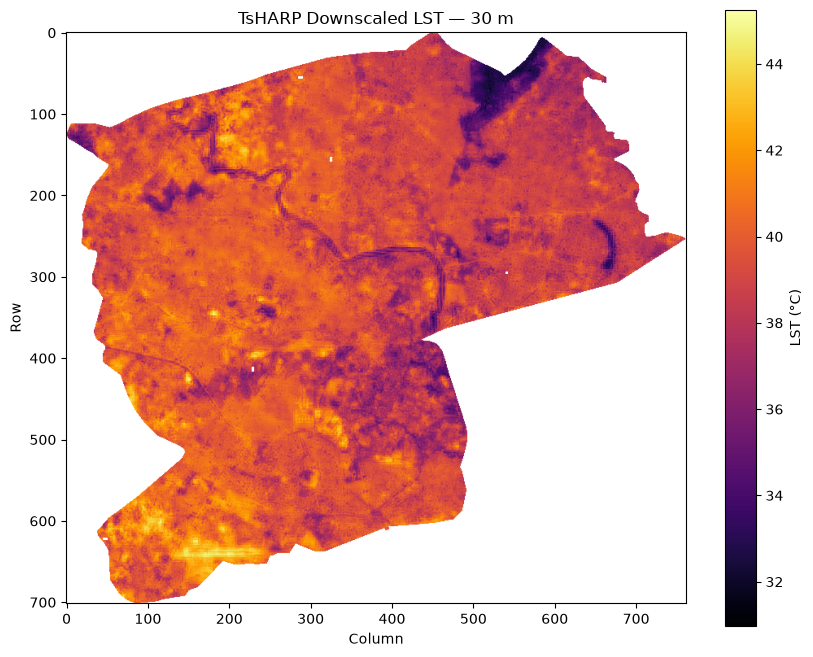

In [131]:
plt.figure(figsize=(10, 8))

plt.imshow(
    tsharp_plot,
    cmap="inferno",
    vmin=common_min,
    vmax=common_max
)

plt.colorbar(label="LST (°C)")
plt.title("TsHARP Downscaled LST — 30 m")
plt.xlabel("Column")
plt.ylabel("Row")

plt.savefig(
    FIGURES_DIR / "notebook_6" / "comparison_tsharp_30m.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

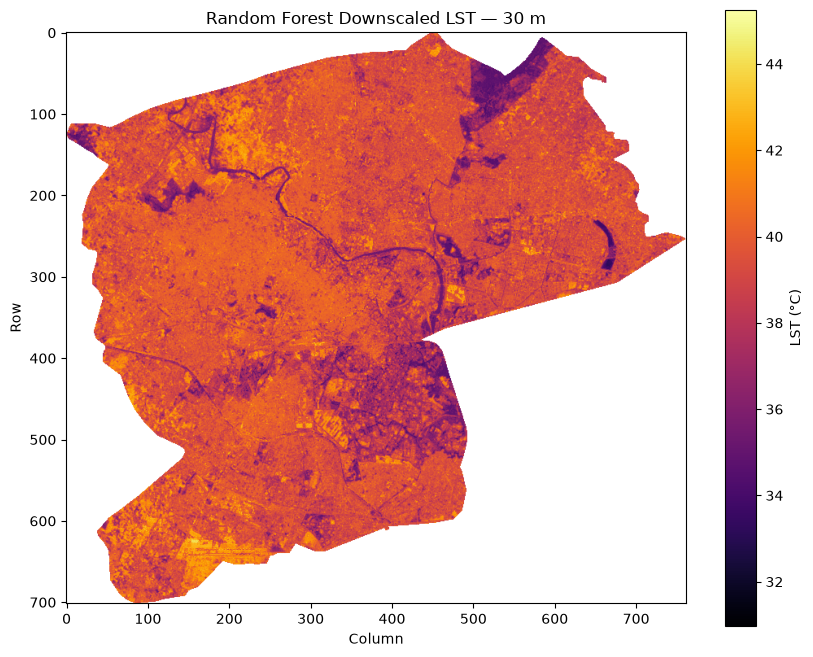

In [132]:
plt.figure(figsize=(10, 8))

plt.imshow(
    rf_plot,
    cmap="inferno",
    vmin=common_min,
    vmax=common_max
)

plt.colorbar(label="LST (°C)")
plt.title("Random Forest Downscaled LST — 30 m")
plt.xlabel("Column")
plt.ylabel("Row")

plt.savefig(
    FIGURES_DIR / "notebook_6" / "comparison_rf_30m.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

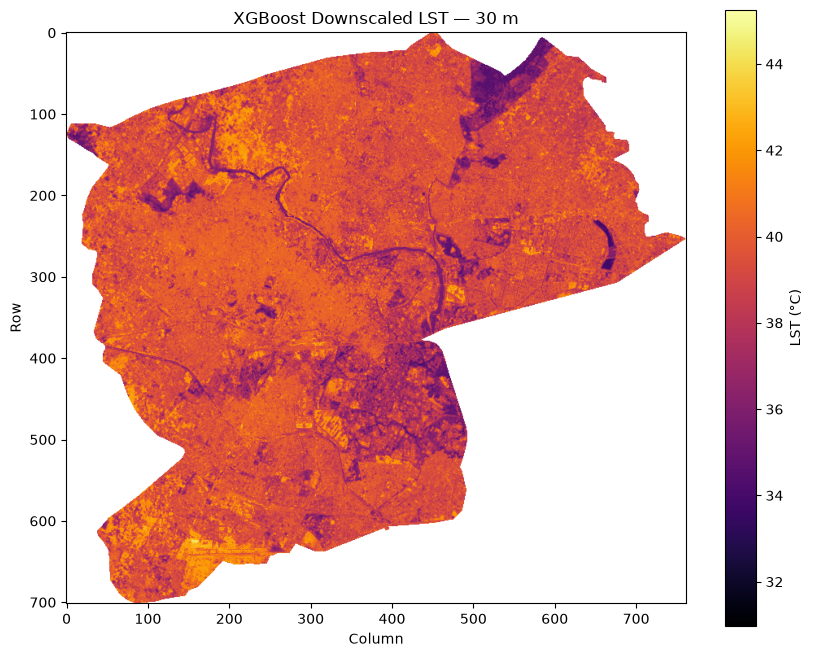

In [133]:
plt.figure(figsize=(10, 8))

plt.imshow(
    xgb_plot,
    cmap="inferno",
    vmin=common_min,
    vmax=common_max
)

plt.colorbar(label="LST (°C)")
plt.title("XGBoost Downscaled LST — 30 m")
plt.xlabel("Column")
plt.ylabel("Row")

plt.savefig(
    FIGURES_DIR / "notebook_6" / "comparison_xgb_30m.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Using a common temperature scale allows direct visual comparison of the three 30 m LST products.

The three approaches reproduce similar broad spatial thermal patterns, while differences are visible in the magnitude and spatial distribution of warmer and cooler areas.

TsHARP preserves a wider thermal range than the machine-learning products, whereas Random Forest and XGBoost produce comparatively smoother thermal fields.

These visual differences are evaluated quantitatively using the model statistics, consistency metrics, and difference maps rather than being interpreted from the maps alone.

## Spatial Difference Analysis

Difference maps are used to quantify and visualize spatial disagreement between the downscaled LST products.

Three pairwise differences are examined:

- Random Forest − TsHARP
- XGBoost − TsHARP
- XGBoost − Random Forest

Positive values indicate that the first model produces higher LST than the second model, while negative values indicate lower LST.

A symmetric color range centered at zero is used so that positive and negative differences can be interpreted consistently.

In [134]:
rf_minus_tsharp = rf_plot - tsharp_plot
xgb_minus_tsharp = xgb_plot - tsharp_plot
xgb_minus_rf = xgb_plot - rf_plot

In [135]:
print("RF - TsHARP")
print("Min :", np.nanmin(rf_minus_tsharp))
print("Max :", np.nanmax(rf_minus_tsharp))
print("Mean:", np.nanmean(rf_minus_tsharp))
print("Std :", np.nanstd(rf_minus_tsharp))

print("\nXGBoost - TsHARP")
print("Min :", np.nanmin(xgb_minus_tsharp))
print("Max :", np.nanmax(xgb_minus_tsharp))
print("Mean:", np.nanmean(xgb_minus_tsharp))
print("Std :", np.nanstd(xgb_minus_tsharp))

print("\nXGBoost - RF")
print("Min :", np.nanmin(xgb_minus_rf))
print("Max :", np.nanmax(xgb_minus_rf))
print("Mean:", np.nanmean(xgb_minus_rf))
print("Std :", np.nanstd(xgb_minus_rf))

RF - TsHARP
Min : -7.3674736
Max : 5.718437
Mean: 0.044092815
Std : 0.97413933

XGBoost - TsHARP
Min : -7.0660896
Max : 5.849125
Mean: 0.033776965
Std : 0.96371096

XGBoost - RF
Min : -2.3589287
Max : 2.8037834
Mean: -0.010315597
Std : 0.23433524


In [136]:
difference_values = np.concatenate([
    rf_minus_tsharp[np.isfinite(rf_minus_tsharp)],
    xgb_minus_tsharp[np.isfinite(xgb_minus_tsharp)],
    xgb_minus_rf[np.isfinite(xgb_minus_rf)]
])

difference_limit = np.nanmax(
    np.abs(difference_values)
)

print("Common difference limit:", difference_limit)

Common difference limit: 7.3674736


In [137]:
vmin_diff = -difference_limit
vmax_diff = difference_limit

print("Difference scale:")
print("Minimum:", vmin_diff)
print("Maximum:", vmax_diff)

Difference scale:
Minimum: -7.3674736
Maximum: 7.3674736


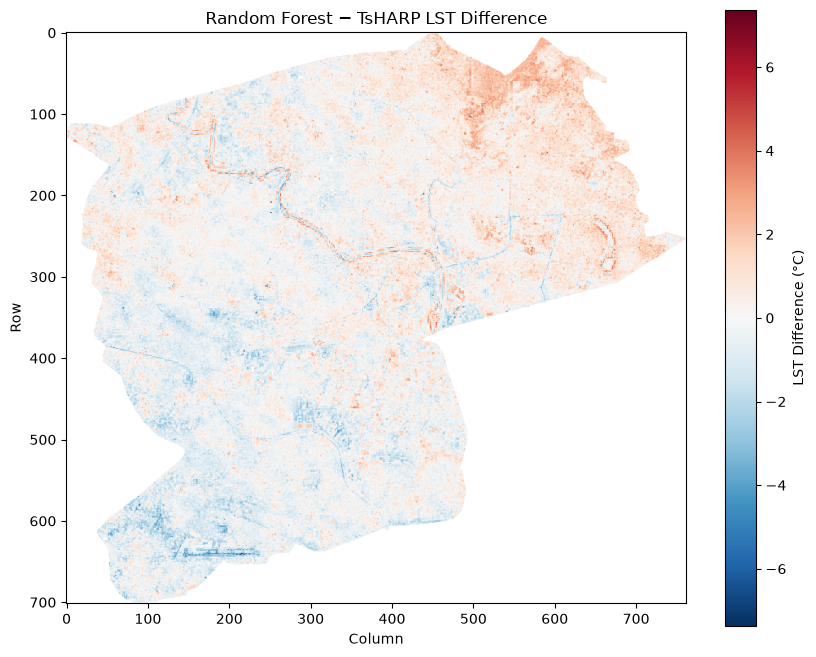

In [138]:
plt.figure(figsize=(10, 8))

plt.imshow(
    rf_minus_tsharp,
    cmap="RdBu_r",
    vmin=vmin_diff,
    vmax=vmax_diff
)

plt.colorbar(
    label="LST Difference (°C)"
)

plt.title("Random Forest − TsHARP LST Difference")
plt.xlabel("Column")
plt.ylabel("Row")

plt.savefig(
    FIGURES_DIR / "notebook_6" / "difference_rf_minus_tsharp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

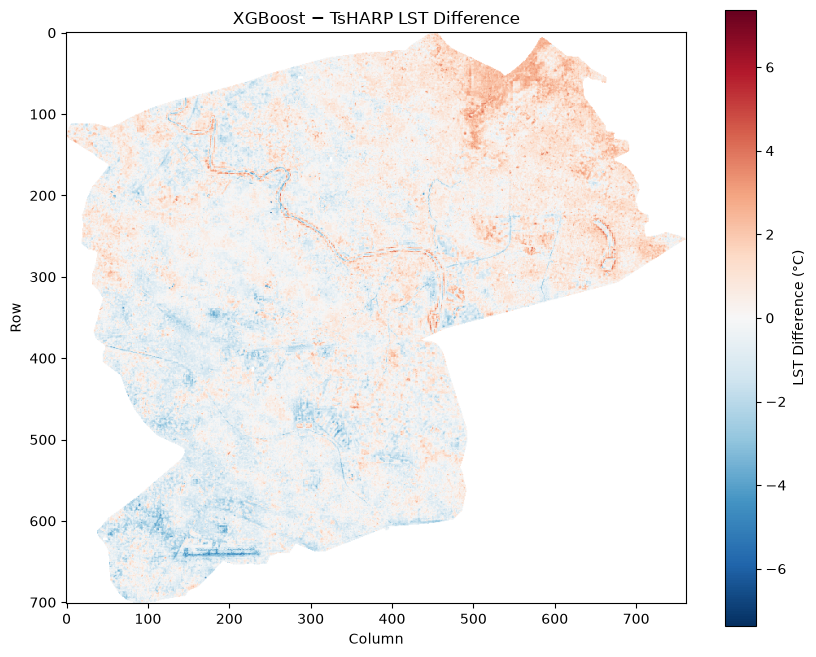

In [139]:
plt.figure(figsize=(10, 8))

plt.imshow(
    xgb_minus_tsharp,
    cmap="RdBu_r",
    vmin=vmin_diff,
    vmax=vmax_diff
)

plt.colorbar(
    label="LST Difference (°C)"
)

plt.title("XGBoost − TsHARP LST Difference")
plt.xlabel("Column")
plt.ylabel("Row")

plt.savefig(
    FIGURES_DIR / "notebook_6" / "difference_xgb_minus_tsharp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

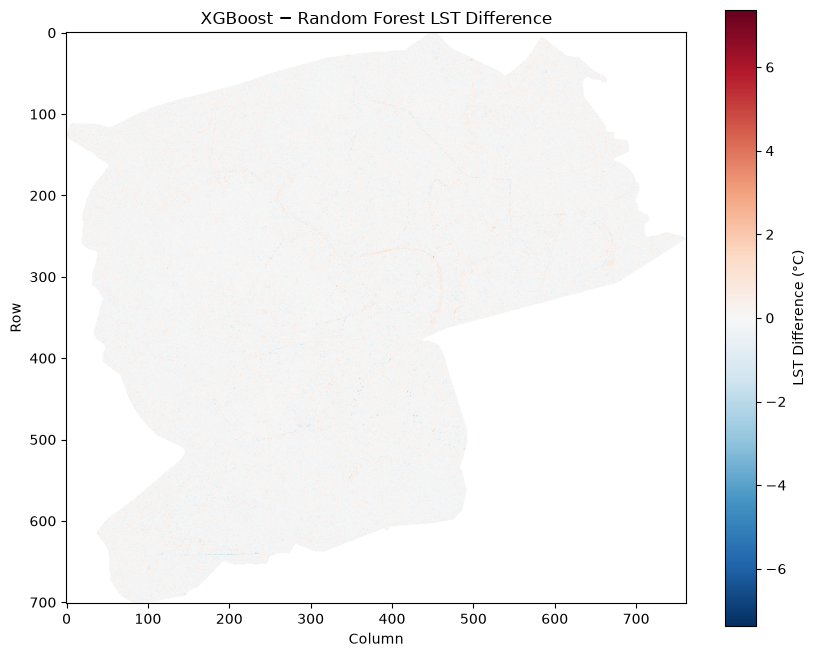

In [140]:
plt.figure(figsize=(10, 8))

plt.imshow(
    xgb_minus_rf,
    cmap="RdBu_r",
    vmin=vmin_diff,
    vmax=vmax_diff
)

plt.colorbar(
    label="LST Difference (°C)"
)

plt.title("XGBoost − Random Forest LST Difference")
plt.xlabel("Column")
plt.ylabel("Row")

plt.savefig(
    FIGURES_DIR / "notebook_6" / "difference_xgb_minus_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Difference Analysis — Observation

The Random Forest and XGBoost products show relatively small spatial differences. The mean difference between XGBoost and Random Forest is approximately −0.01 °C, with a standard deviation of 0.234 °C, indicating that the two machine-learning approaches produce broadly similar 30 m thermal patterns.

In contrast, both machine-learning products show substantially greater differences relative to TsHARP, with standard deviations of approximately 0.97 °C for both comparisons.

The mean differences relative to TsHARP are small and positive, indicating little overall systematic offset between the products. However, the larger standard deviations indicate substantial spatial variation in the differences.

The minimum and maximum difference values represent localized extreme disagreements and should not be interpreted as typical model differences.

In [141]:
abs_difference_results = []

difference_maps = {
    "RF - TsHARP": rf_minus_tsharp,
    "XGBoost - TsHARP": xgb_minus_tsharp,
    "XGBoost - RF": xgb_minus_rf
}

for comparison, difference in difference_maps.items():

    valid_difference = difference[
        np.isfinite(difference)
    ]

    abs_difference_results.append({
        "Comparison": comparison,
        "Mean Absolute Difference": np.mean(
            np.abs(valid_difference)
        ),
        "Median Absolute Difference": np.median(
            np.abs(valid_difference)
        ),
        "Maximum Absolute Difference": np.max(
            np.abs(valid_difference)
        )
    })

absolute_difference_df = pd.DataFrame(
    abs_difference_results
)

absolute_difference_df

,Comparison,Mean Absolute Difference,Median Absolute Difference,Maximum Absolute Difference
0,RF - TsHARP,0.743877,0.584734,7.367474
1,XGBoost - TsHARP,0.736780,0.580910,7.066090
2,XGBoost - RF,0.174957,0.136547,2.803783


### Absolute Difference Analysis — Observation

The absolute difference analysis shows that Random Forest and XGBoost produce substantially more similar 30 m LST fields than either machine-learning model produces relative to TsHARP.

The mean absolute difference between XGBoost and Random Forest is 0.175 °C, with a median absolute difference of 0.137 °C. In comparison, the mean absolute differences between RF and TsHARP and between XGBoost and TsHARP are 0.744 °C and 0.737 °C, respectively.

This indicates that the two machine-learning approaches produce broadly similar spatial thermal patterns despite using different ensemble learning algorithms.

The larger differences between the machine-learning products and TsHARP indicate that the statistical and machine-learning approaches generate substantially different fine-resolution thermal fields. These differences are investigated further using the temperature distributions and spatial comparison results.

## LST Distribution Comparison

The distributions of the three 30 m LST products are compared to examine differences in their thermal range, central tendency, and spatial variability.

A common temperature axis is used so that the distribution shapes can be compared directly.

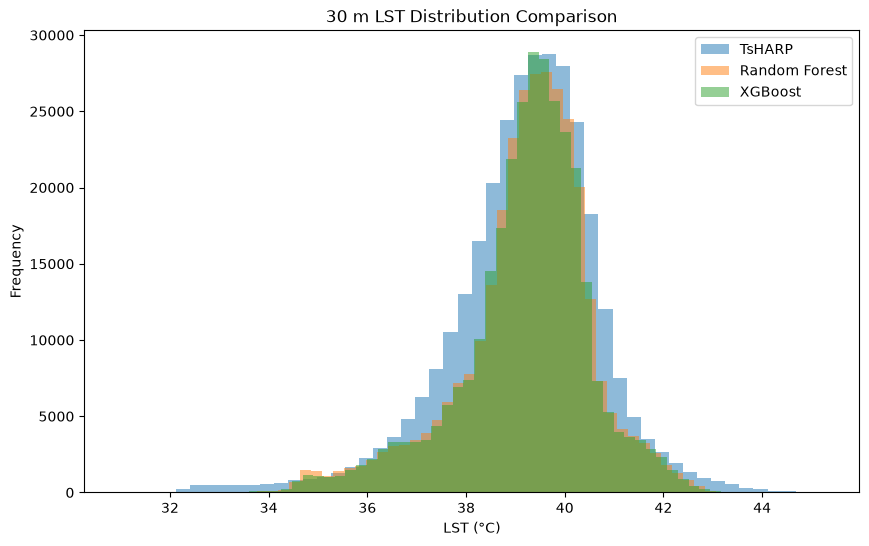

In [142]:
plt.figure(figsize=(10, 6))

plt.hist(
    tsharp_plot[np.isfinite(tsharp_plot)],
    bins=50,
    alpha=0.5,
    label="TsHARP"
)

plt.hist(
    rf_plot[np.isfinite(rf_plot)],
    bins=50,
    alpha=0.5,
    label="Random Forest"
)

plt.hist(
    xgb_plot[np.isfinite(xgb_plot)],
    bins=50,
    alpha=0.5,
    label="XGBoost"
)

plt.xlabel("LST (°C)")
plt.ylabel("Frequency")
plt.title("30 m LST Distribution Comparison")

plt.legend()

plt.savefig(
    FIGURES_DIR / "notebook_6" / "comparison_lst_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### LST Distribution — Observation

The three 30 m LST products show similar central distributions but differ in their overall thermal spread.

TsHARP exhibits the broadest distribution, with greater representation of both cooler and hotter temperatures. This is consistent with its higher standard deviation and wider minimum-to-maximum range.

Random Forest and XGBoost produce substantially narrower and highly overlapping distributions, indicating similar thermal variability between the two machine-learning approaches.

The narrower ML distributions suggest stronger compression of the thermal extremes compared with TsHARP. However, a wider distribution is not necessarily evidence of greater accuracy; the realism of the thermal extremes must be evaluated using the available validation and consistency evidence.

## Overall Model Comparison

The results from the preceding analyses are combined to compare the three downscaling approaches.

Because TsHARP and the machine-learning models were not evaluated using identical independent validation procedures, metrics from different evaluation frameworks are kept separate rather than being treated as directly equivalent.

The comparison therefore distinguishes between:

1. Independent spatial testing available for the machine-learning models.
2. 30 m → 90 m consistency assessment for all three products.
3. Spatial characteristics and differences of the generated 30 m products.

In [143]:
ml_results

,Model,MAE,RMSE,R2
0,Random Forest,0.742,0.968,0.684
1,XGBoost,0.741,0.970,0.683


In [144]:
consistency_df

,Model,MAE,RMSE,R2,Bias
0,TsHARP,0.000002,0.000003,1.000000,3.018724e-08
1,Random Forest,0.637307,0.828625,0.690880,4.580944e-02
2,XGBoost,0.643180,0.836417,0.685039,3.570386e-02


In [145]:
product_stats_df

,Model,Min,Max,Mean,Std
0,TsHARP,30.975880,45.252350,39.176819,1.539358
1,Random Forest,33.090565,44.170734,39.220787,1.353049
2,XGBoost,33.601151,44.467197,39.210472,1.326293


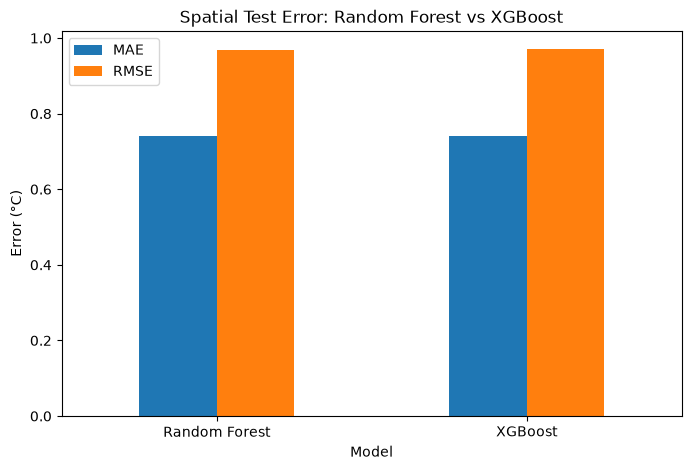

In [146]:
performance_plot = ml_results.set_index("Model")

performance_plot[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Error (°C)")
plt.title("Spatial Test Error: Random Forest vs XGBoost")
plt.xticks(rotation=0)
plt.legend()

plt.savefig(
    FIGURES_DIR / "notebook_6" / "ml_model_error_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

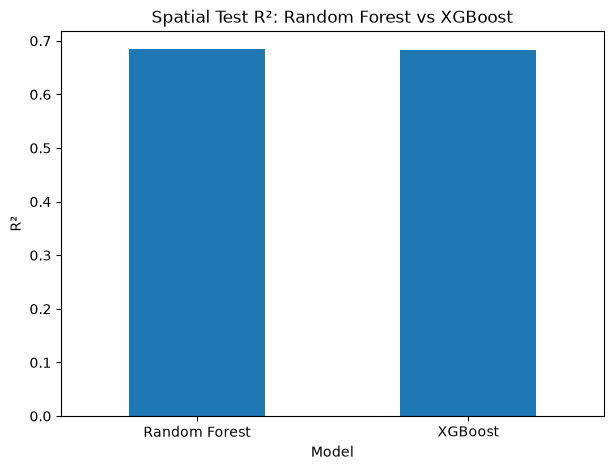

In [147]:
performance_plot["R2"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.ylabel("R²")
plt.title("Spatial Test R²: Random Forest vs XGBoost")
plt.xticks(rotation=0)

plt.savefig(
    FIGURES_DIR / "notebook_6" / "ml_model_r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Machine-Learning Model Comparison — Observation

The spatial test results show very similar performance between Random Forest and XGBoost.

Random Forest achieves an MAE of 0.742 °C, RMSE of 0.968 °C, and R² of 0.684, while XGBoost achieves an MAE of 0.741 °C, RMSE of 0.970 °C, and R² of 0.683.

XGBoost has a marginally lower MAE, whereas Random Forest has marginally lower RMSE and slightly higher R². The differences are very small and do not provide strong evidence that either model is substantially superior under the current spatial validation framework.

Therefore, the two machine-learning models are considered broadly equivalent in predictive performance at this stage.

## Overall Comparison and Interpretation

The three downscaling approaches show different characteristics across the evaluated dimensions.

### TsHARP

TsHARP produces the widest thermal range and highest spatial variability among the three 30 m products. Its 30 m → 90 m reconstruction is nearly exact because the method preserves the original coarse-resolution thermal field by construction. Therefore, this consistency result should not be interpreted as independent predictive validation.

### Random Forest

Random Forest provides strong spatial-test performance with an MAE of 0.742 °C, RMSE of 0.968 °C, and R² of 0.684. Its generated 30 m product has a narrower thermal range than TsHARP and shows relatively strong consistency with the original 90 m LST.

### XGBoost

XGBoost provides spatial-test performance very similar to Random Forest, with an MAE of 0.741 °C, RMSE of 0.970 °C, and R² of 0.683. Its 30 m product has the narrowest thermal distribution among the three approaches and is spatially very similar to the Random Forest product.

### Overall Finding

The two machine-learning approaches demonstrate nearly identical spatial generalization performance and produce highly similar 30 m LST products. Their mean absolute spatial difference is only 0.175 °C.

TsHARP produces a substantially different and broader thermal field, with greater representation of thermal extremes. However, the available TsHARP evaluation is not directly comparable to the spatially withheld ML test and therefore cannot be used alone to rank TsHARP against the machine-learning models.

The results indicate that model selection should consider not only predictive accuracy but also spatial behaviour, thermal-range preservation, and the intended application of the downscaled LST product.

In [148]:
(PROJECT_DIR / "results").mkdir(
    parents=True,
    exist_ok=True
)

In [149]:
ml_results.to_csv(
    PROJECT_DIR / "results" / "ml_model_performance.csv",
    index=False
)

In [150]:
consistency_df.to_csv(
    PROJECT_DIR / "results" / "30m_90m_consistency_comparison.csv",
    index=False
)

In [151]:
product_stats_df.to_csv(
    PROJECT_DIR / "results" / "30m_product_statistics.csv",
    index=False
)

In [152]:
absolute_difference_df.to_csv(
    PROJECT_DIR / "results" / "spatial_difference_statistics.csv",
    index=False
)

## Final Observation

The comparison of TsHARP, Random Forest, and XGBoost shows that the three approaches produce broadly similar large-scale thermal patterns but differ substantially in their representation of fine-scale thermal variability.

TsHARP produced the widest 30 m LST range (30.98–45.25 °C) and the highest spatial variability (standard deviation = 1.539 °C). Its 30 m → 90 m reconstruction showed near-perfect consistency with the original 90 m LST. However, this near-perfect reconstruction is a property of the TsHARP formulation and should not be interpreted as independent predictive validation. Therefore, the TsHARP consistency metrics cannot be directly compared with the spatially withheld machine-learning test metrics.

Random Forest and XGBoost showed nearly identical spatial generalization performance. Random Forest achieved a spatial test MAE of 0.742 °C, RMSE of 0.968 °C, and R² of 0.684, while XGBoost achieved an MAE of 0.741 °C, RMSE of 0.970 °C, and R² of 0.683. The differences between the two models are very small and do not provide strong evidence that either model is substantially superior under the current spatial validation framework.

The two machine-learning products were also highly similar spatially. The mean absolute difference between the XGBoost and Random Forest 30 m LST products was 0.175 °C, with a median absolute difference of 0.137 °C. In contrast, the mean absolute differences between Random Forest and TsHARP and between XGBoost and TsHARP were 0.744 °C and 0.737 °C, respectively.

The LST distribution analysis showed that Random Forest and XGBoost produce narrower and highly overlapping thermal distributions, indicating stronger compression of thermal extremes compared with TsHARP. TsHARP preserves a wider range of cooler and hotter values, although the available analyses do not establish whether these additional extremes are more accurate.

Overall, the results indicate that Random Forest and XGBoost provide comparable spatial predictive performance and generate highly similar 30 m LST products, while TsHARP produces a distinct downscaled thermal field with greater spatial variability and a wider thermal range. No single approach can be declared universally superior from the current evidence alone because the evaluation frameworks for TsHARP and the machine-learning models are not fully equivalent.

The comparison provides the basis for the next stage of the project: explainable machine-learning analysis using SHAP to investigate how the remote-sensing predictors influence the selected machine-learning downscaling model.